# Pipeline: подготовка данных для сегментации клиентов санатория

**Цель ноутбука:** пройти полный путь от `silver.csv` до матрицы признаков `X_scaled`,
готовой для передачи в алгоритм кластеризации.

**Выход:** `df_for_model_claster` (436 492 гостя × 13 признаков) + `X_scaled` (numpy array).

**Этапы:**
1. Загрузка и EDA
2. Фильтрация (только известные гости)
3. Признаки ДО схлопывания: nights, season, children, booking_group_size
4. Схлопывание: один заезд = одна строка
5. Очистка: служебные тарифы, nights=0 / >90
6. Инжиниринг признаков
7. Отбор признаков → df_model
8. Агрегация до уровня гостя → df_for_model_claster
9. Импутация + log1p
10. Preprocessing Pipeline (ColumnTransformer) → X_scaled
11. Финальная проверка


## 1. Импорты и настройки

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
plt.rcParams['figure.dpi'] = 100
print("Импорты OK")

Импорты OK


## 2. Загрузка данных и EDA

`silver.csv` — 565 816 строк, 24 колонки, уровень обработки silver.

In [2]:
df = pd.read_csv('silver.csv')
print(f"Загружено: {df.shape[0]:,} строк × {df.shape[1]} колонок")
df.head(3)

Загружено: 565,816 строк × 24 колонок


,Unnamed: 0,created_dt,check_in_dt,check_out_dt,activity_dt,is_valid,tariff,discount,composition,grp,grp_norm,room_type,currency,guest_id,guest_last_name,citizenship,gender,guest_age,prev_stays,rooms,places,extra_places,children,adults
0,0,2020-12-01,2021-01-30 14:00:00,2021-02-01 12:00:00,2021-02-01 12:00:00,0,Все Включено 2021,25.0,NaN,923 160,923160,К -Комфорт,Руб.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
1,1,2020-12-01,2020-12-15 14:00:00,2020-12-22 12:00:00,2020-12-22 12:00:00,1,Открытый Юг/Доступный Юг от 7 суток 2020г.,NaN,NaN,923 196,923196,К-VS - VS-Комфорт,Руб.,1370402.0,Санкин,РОССИЯ,Мужской,61.0,1.0,NaN,1.0,NaN,NaN,NaN
2,2,2020-12-01,2021-01-30 14:00:00,2021-02-04 12:00:00,2021-02-04 12:00:00,0,Все Включено 2021,25.0,NaN,923 143,923143,К+- Комфорт+,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN


In [3]:
# Сводная таблица: тип, уникальных значений, % пропусков
eda = pd.DataFrame({
    'dtype'    : df.dtypes.astype(str),
    'unique'   : df.nunique(),
    'null_%'   : (df.isna().mean() * 100).round(1),
}).reset_index().rename(columns={'index': 'column'})
print(f"is_valid_for_rfm распределение: {df['is_valid'].value_counts().to_dict()}")
print()
print(eda.to_string(index=False))

is_valid_for_rfm распределение: {1: 521143, 0: 44673}

         column   dtype  unique  null_%
     Unnamed: 0   int64  565816     0.0
     created_dt     str    2163     0.0
    check_in_dt     str    6589     0.0
   check_out_dt     str    3799     0.0
    activity_dt     str    3799     0.0
       is_valid   int64       2     0.0
         tariff     str     634     0.0
       discount float64      66    84.1
    composition     str      28    59.7
            grp     str  144064     0.0
       grp_norm   int64  144064     0.0
      room_type     str      24     0.0
       currency     str       1     3.1
       guest_id float64  447267     7.9
guest_last_name     str  147597     7.9
    citizenship     str      40    23.5
         gender     str       2    23.4
      guest_age float64     270    31.9
     prev_stays float64      74    32.2
          rooms float64      28    95.0
         places float64      44    21.9
   extra_places float64      25    80.5
       children float64  

In [4]:
# Конвертация дат
for col in ['created_dt', 'check_in_dt', 'check_out_dt', 'activity_dt']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

print("Диапазон заездов:")
print(f"  check_in_dt:  {df['check_in_dt'].min().date()} → {df['check_in_dt'].max().date()}")
print(f"  check_out_dt: {df['check_out_dt'].min().date()} → {df['check_out_dt'].max().date()}")

Диапазон заездов:
  check_in_dt:  2019-01-01 → 2025-10-30
  check_out_dt: 2019-11-27 → 2029-10-07


## 3. Фильтрация: только известные гости (`is_valid_for_rfm == 1`)

Анонимные гости (is_valid=0, 44 673 строки) — без guest_id.
Их нельзя персонализировать, поэтому для **кластеризации** не используем.
Для прогноза спроса (Модель 2) они пойдут обратно.

In [5]:
n_total = len(df)
df = df[df['is_valid'] == 1].copy()

print(f"До фильтра:  {n_total:,} строк")
print(f"После:       {len(df):,} строк  ({len(df)/n_total*100:.1f}%)")
print(f"Уникальных гостей:  {df['guest_id'].nunique():,}")
print(f"Уникальных заездов: {df['grp_norm'].nunique():,}")

До фильтра:  565,816 строк
После:       521,143 строк  (92.1%)
Уникальных гостей:  447,267
Уникальных заездов: 142,703


## 4. Признаки ДО схлопывания

`nights` и `season` считаются по каждой тарифной строке — это единственный момент,
когда у нас есть отдельные периоды с точными датами.
`children` распространяется по бронированию до схлопывания — иначе 9% вместо 27% семей.

In [6]:
# ── 4.1 nights ────────────────────────────────────────────────────────────
# normalize() убирает время → считаем чистые ночи
df['nights'] = (
    df['check_out_dt'].dt.normalize() - df['check_in_dt'].dt.normalize()
).dt.days.clip(lower=0)

print(f"nights: min={df['nights'].min()}, max={df['nights'].max()}, "
      f"median={df['nights'].median()}")

nights: min=0, max=2024, median=6.0


In [7]:
# ── 4.2 season ────────────────────────────────────────────────────────────
def _get_season(month):
    if month in [12, 1, 2]: return 'зима'
    if month in [3, 4, 5]:  return 'весна'
    if month in [6, 7, 8]:  return 'лето'
    return 'осень'

df['season'] = df['check_in_dt'].dt.month.map(_get_season)
print("Распределение по сезонам:")
print(df['season'].value_counts().to_string())

Распределение по сезонам:
season
лето     151411
весна    131288
зима     124586
осень    113858


In [8]:
# ── 4.3 Распространение children по бронированию ДО схлопывания ──────────
#
# Проблема: adults/children — атрибут НОМЕРА, записан только в одной строке.
#   Фимина (1829): children=NaN → children здесь, т.к. состав записан у неё
#   Фимин  (1828): children=NaN → он в том же номере, но у него NaN
#
# Без исправления: 9% гостей с has_children=1 (занижено в 3 раза)
# После:          ~27%
#
# Решение: transform('max') внутри grp_norm для малых групп (≤10 чел = семья/пара).
# Для больших групп (>10) не распространяем — неоднородный состав.

grp_size = df.groupby('grp_norm')['guest_id'].transform('nunique')
small_mask = grp_size <= 10

df.loc[small_mask, 'children'] = (
    df[small_mask]
    .groupby('grp_norm')['children']
    .transform('max')
)

n_with_children = (df['children'] > 0).sum()
print(f"Строк с children > 0: {n_with_children:,}  (до исправления было ~39,449)")

Строк с children > 0: 132,027  (до исправления было ~39,449)


## 5. Схлопывание: один (grp_norm, guest_id) = одна строка

### Зачем

Один гость может иметь несколько строк в рамках одного заезда (смена тарифа, продление).
Это технический артефакт — `groupby(grp_norm, guest_id)` схлопывает их в одну строку.

**Важно:** гости из одной группы (семья, корпоратив) — **разные** `guest_id`,
они остаются отдельными строками после группировки.

### Правила агрегации

| Поле | Агрегация | Обоснование |
|---|---|---|
| `check_in_dt` | min | Начало заезда |
| `check_out_dt` | max | Конец заезда |
| `nights` | sum | Сумма всех тарифных периодов |
| `tariff`, `room_type` | первый ненулевой | Основной тариф/номер |
| `guest_age`, `gender` | первый ненулевой | Атрибут гостя (исправлено: было `first`) |
| `discount` | mean | Средняя скидка по периодам |
| `prev_stays` | max | Все строки одинаковы (из CRM) |

In [9]:
_first_nonnull = lambda x: x.dropna().iloc[0] if x.notna().any() else np.nan

df_deduped = (
    df.groupby(['grp_norm', 'guest_id'], as_index=False)
    .agg(
        check_in_dt  = ('check_in_dt',  'min'),
        check_out_dt = ('check_out_dt', 'max'),
        activity_dt  = ('activity_dt',  'max'),
        nights       = ('nights',       'sum'),
        season       = ('season',       lambda x: x.mode().iloc[0]),
        tariff       = ('tariff',       lambda x: x.dropna().iloc[0]
                                        if x.notna().any() else None),
        room_type    = ('room_type',    lambda x: x.dropna().iloc[0]
                                        if x.notna().any() else None),
        children     = ('children',     'max'),
        adults       = ('adults',       'max'),
        places       = ('places',       'max'),
        guest_age    = ('guest_age',    _first_nonnull),
        gender       = ('gender',       _first_nonnull),
        discount     = ('discount',     'mean'),
        prev_stays   = ('prev_stays',   'max'),
    )
)

# booking_group_size: сколько уникальных гостей в одном бронировании
# Это поведенческий признак: соло=1, пара=2, семья=3-4, корпоратив=10+
# Считаем ЗДЕСЬ — после схлопывания тарифных дублей, но ДО агрегации по гостям
df_deduped['booking_group_size'] = (
    df_deduped.groupby('grp_norm')['guest_id'].transform('nunique')
)

print(f"Строк до схлопывания:    {len(df):,}")
print(f"Строк после (заездов):   {len(df_deduped):,}")
print(f"Схлопнуто тарифных дублей: {len(df) - len(df_deduped):,}")
print(f"\nbooking_group_size распределение (топ-10):")
print(df_deduped['booking_group_size'].value_counts().head(10).to_string())


Строк до схлопывания:    521,143
Строк после (заездов):   516,414
Схлопнуто тарифных дублей: 4,729

booking_group_size распределение (топ-10):
booking_group_size
2      105160
3       92670
4       64712
1       32332
5       17770
200     10000
100      9600
6        9084
7        5096
8        4344


## 6. Очистка: служебные тарифы и аномальные nights

### Удаляем из df_deduped:
1. **Служебные тарифы** (`Служебный`, `СОТРУДНИКИ`, `Сотрудник`) — сотрудники, не гости
2. **Административные** (`НЕ СЕЛИТЬ`) — технические записи
3. **nights == 0** — заселение и выезд в один день, не полноценный заезд
4. **nights > 90** — аномалии данных (max=367 у «Новогоднего тура» — ошибка дат)

In [10]:
n0 = len(df_deduped)

# Служебные тарифы
service_mask = df_deduped['tariff'].str.contains(
    r'Служебный|СОТРУДНИКИ|Сотрудник|НЕ СЕЛИТЬ',
    case=False, na=False
)
df_deduped = df_deduped[~service_mask].copy()
print(f"Удалено служебных/административных: {n0 - len(df_deduped):,}")

# Аномальные nights
n1 = len(df_deduped)
df_clean = df_deduped[
    (df_deduped['nights'] > 0) & (df_deduped['nights'] <= 90)
].copy()

print(f"Удалено nights==0:   {(df_deduped['nights'] == 0).sum():,}")
print(f"Удалено nights>90:   {(df_deduped['nights'] > 90).sum():,}")
print(f"\ndf_clean: {len(df_clean):,} строк (заездов)")

Удалено служебных/административных: 30,354
Удалено nights==0:   144
Удалено nights>90:   19

df_clean: 485,897 строк (заездов)


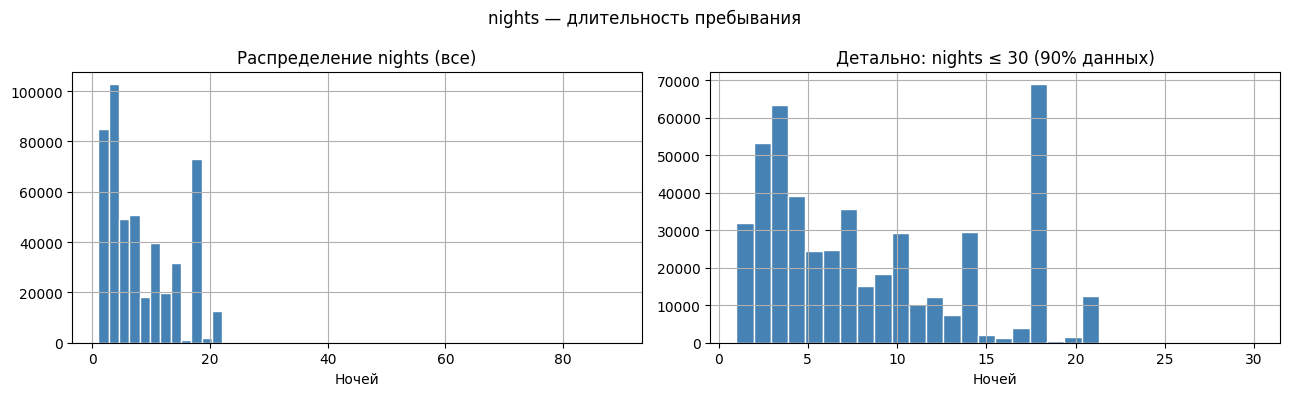

count    485897.0
mean          8.3
std           6.1
min           1.0
25%           3.0
50%           7.0
75%          13.0
max          89.0
Name: nights, dtype: float64


In [11]:
# Быстрая проверка распределения nights
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df_clean['nights'].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Распределение nights (все)')
axes[0].set_xlabel('Ночей')

df_clean[df_clean['nights'] <= 30]['nights'].hist(
    bins=30, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Детально: nights ≤ 30 (90% данных)')
axes[1].set_xlabel('Ночей')

plt.suptitle('nights — длительность пребывания', fontsize=12)
plt.tight_layout()
plt.show()

print(df_clean['nights'].describe().round(1))

## 7. Инжиниринг признаков

Строим 12 признаков, которые войдут в матрицу X.
Каждый признак — маркетинговый сигнал для рекомендатора:
«кому и каким оффером закрыть недозагруженность».

### 7.1 lead_time — горизонт бронирования

Сколько дней прошло от создания брони до заезда.
- **Короткий** (1–14 дней): спонтанные гости → last-minute акции
- **Длинный** (60+ дней): планировщики → early bird офферы

In [12]:
# created_dt уже конвертирован выше; берём минимум по (grp_norm, guest_id)
created = (
    df.groupby(['grp_norm', 'guest_id'])['created_dt']
    .min()
    .reset_index()
)
df_clean = df_clean.merge(created, on=['grp_norm', 'guest_id'], how='left')
df_clean['lead_time'] = (
    df_clean['check_in_dt'] - df_clean['created_dt']
).dt.days.clip(lower=0)

print(f"Пропуски lead_time: {df_clean['lead_time'].isna().sum():,}")
print(df_clean['lead_time'].describe().round(1))

Пропуски lead_time: 0
count    485897.0
mean         78.3
std          84.9
min           0.0
25%          14.0
50%          45.0
75%         118.0
max         689.0
Name: lead_time, dtype: float64


### 7.2 guest_age — очистка аномалий

- `999` — заглушка «возраст неизвестен» (не аномалия числа, а код)
- `> 100` — явные ошибки ввода (max=976 в сырых данных)

In [13]:
before = df_clean['guest_age'].isna().sum()

df_clean['guest_age'] = df_clean['guest_age'].replace(999, np.nan)
df_clean.loc[df_clean['guest_age'] > 100, 'guest_age'] = np.nan

after = df_clean['guest_age'].isna().sum()
print(f"Пропуски guest_age: {before:,} → {after:,} ({after/len(df_clean)*100:.1f}%)")
print(df_clean['guest_age'].dropna().describe().round(1))

Пропуски guest_age: 126,150 → 126,945 (26.1%)
count    358952.0
mean         39.0
std          22.1
min           1.0
25%          16.0
50%          40.0
75%          57.0
max         100.0
Name: guest_age, dtype: float64


### 7.3 tariff_group — 628 тарифов → 8 групп

**Зачем:** конкретные названия тарифов — слишком детальный уровень для кластеризации.
Группа = ценовой сегмент / канал продаж.

| Группа | Паттерн | Маркетинговый смысл |
|---|---|---|
| льготный/корп | ФСС, Согаз, корпор | B2B, партнёры |
| ультра/all-incl | ультра, все включено | Высокий чек |
| стандарт/оптима | стандарт, оптима | Массовый сегмент |
| лечебный | лечени, санатор | Путёвки, особая аудитория |
| новогодний/банкет | новогодн, банкет | Праздничный сегмент |
| событие/группы | фестивал, сборы, турнир | Организованные группы |
| социальный | школьн, серебрян, студент | Льготные группы |
| акция/спецпредл | акция, аквапарк | Промо |
| other | всё остальное | ~10% |


In [14]:
_tariff_rules = [
    ('льготный/корп',      r'фсс|гку|согаз|дирекци|народн|нефтегаз|газпром|юганск|корпор'),
    ('ультра/all-incl',    r'ультра|все включено'),
    ('стандарт/оптима',    r'оптима|стандарт|межсезон|стд'),
    ('новогодний/банкет',  r'новогодн|банкет|праздн'),
    ('лечебный',           r'лечени|оздоров|санатор'),
    ('событие/группы',     r'фестивал|шахмат|шашк|сборы|планета|турнир|выходного дня'),
    ('социальный',         r'школьн|студент|серебрян|золотая|мечтай|возраст'),
    ('акция/спецпредл',    r'аквапарк|акция|спецпредл'),
]

def _map_tariff(t):
    if pd.isna(t): return 'other'
    t_lower = t.lower()
    for group, pattern in _tariff_rules:
        if __import__('re').search(pattern, t_lower):
            return group
    return 'other'

df_clean['tariff_group'] = df_clean['tariff'].map(_map_tariff)

coverage = (df_clean['tariff_group'] != 'other').mean()
print(f"Покрытие именованными группами: {coverage*100:.1f}%")
print(df_clean['tariff_group'].value_counts().to_string())

Покрытие именованными группами: 90.0%
tariff_group
ультра/all-incl      197353
льготный/корп        103457
стандарт/оптима       64125
other                 48430
событие/группы        34073
новогодний/банкет     20621
социальный            12401
лечебный               4319
акция/спецпредл        1118


### 7.4 room_group — 24 типа номеров → 5 групп

Категория номера определяет, какой сегмент гостей может закрыть недозагруженность.

In [15]:
def _map_room(r):
    if pd.isna(r): return 'other'
    r = r.lower()
    if any(x in r for x in ['люкс', 'lux', 'suite', 'полулюкс']): return 'люкс'
    if 'комфорт' in r:                                              return 'комфорт'
    if any(x in r for x in ['стандарт', 'стд']):                   return 'стандарт'
    if any(x in r for x in ['апарт', 'берлин']):                   return 'апартаменты'
    return 'other'

df_clean['room_group'] = df_clean['room_type'].map(_map_room)

print(f"room_group распределение:")
print(df_clean['room_group'].value_counts().to_string())

room_group распределение:
room_group
стандарт       284008
комфорт        195069
люкс             4834
апартаменты      1897
other              89


### 7.5 Числовые и бинарные признаки

| Признак | Тип | Бизнес-смысл |
|---|---|---|
| `discount_rate` | num | Ценовая чувствительность (0–100%) |
| `has_children` | bin | Семейный сегмент → нужны семейные программы |
| `is_weekend_in` | bin | Weekend-турист (пятница/суббота) |
| `month_sin`, `month_cos` | num | Циклическая сезонность (sin/cos вместо числа месяца) |

In [16]:
# discount_rate: скидка как % (NaN = нет скидки = 0)
df_clean['discount_rate'] = df_clean['discount'].clip(0, 100).fillna(0)

# has_children: приезжал с детьми (после propagation выше)
df_clean['has_children'] = (df_clean['children'] > 0).astype(int)

# is_weekend_in: заезд в пятницу (4) или субботу (5)
df_clean['is_weekend_in'] = (df_clean['check_in_dt'].dt.dayofweek >= 4).astype(int)

# Циклическая сезонность: декабрь и январь — соседние, числовой месяц создаёт ложное расстояние 11
month = df_clean['check_in_dt'].dt.month
df_clean['month_sin'] = np.sin(2 * np.pi * month / 12)
df_clean['month_cos'] = np.cos(2 * np.pi * month / 12)

# Переименовываем nights → stay_duration
df_clean = df_clean.rename(columns={'nights': 'stay_duration'})

print("Доли бинарных признаков:")
print(f"  has_children  = {df_clean['has_children'].mean()*100:.1f}%  гостей приезжали с детьми")
print(f"  is_weekend_in = {df_clean['is_weekend_in'].mean()*100:.1f}%  заездов в пятницу/субботу")
print(f"  discount_rate > 0: {(df_clean['discount_rate'] > 0).mean()*100:.1f}%  гостей имели скидку")

Доли бинарных признаков:
  has_children  = 26.9%  гостей приезжали с детьми
  is_weekend_in = 45.1%  заездов в пятницу/субботу
  discount_rate > 0: 16.3%  гостей имели скидку


## 8. Отбор признаков → df_model

### Включены (13 признаков)

| Признак | Тип | Почему |
|---|---|---|
| stay_duration | num | Длительность пребывания |
| lead_time | num | Горизонт бронирования |
| guest_age | num | Возраст |
| prev_stays | num | Лояльность / история по CRM |
| discount_rate | num | Ценовая чувствительность |
| month_sin, month_cos | num | Сезонность без ложного разрыва декабрь-январь |
| **booking_group_size** | **num** | **Размер группы заезда: соло=1, пара=2, семья=3-4, корпоратив=10+** |
| tariff_group | cat | Ценовой сегмент |
| room_group | cat | Категория номера |
| gender | cat | Пол |
| has_children | bin | Семейный сегмент |
| is_weekend_in | bin | Weekend-паттерн |

### Почему booking_group_size информативен

`grp_norm` — это ID бронирования. К одному бронированию могут быть прикреплены
несколько гостей (семья, пара, корпоратив). Сам `grp_norm` как ID бесполезен,
но **количество уникальных гостей внутри бронирования** несёт маркетинговый смысл:

- Гость с `booking_group_size=1` всегда едет один → вероятно, бизнес-турист
- `booking_group_size=2` + `has_children=0` → скорее пара
- `booking_group_size=4` + `has_children=1` → семья с детьми
- `booking_group_size=15` + `tariff_group='льготный/корп'` → корпоративная группа

Это не дублирует `has_children` (не знает размер группы без детей)
и не дублирует `tariff_group` (семья может быть на любом тарифе).

### Исключены (с обоснованием)

| Признак | Причина исключения |
|---|---|
| `has_discount` | corr=0.86 с `discount_rate` → двойной вес |
| `is_repeat` | Бинаризация `prev_stays` → меньше информации |
| `n_stays` | corr=0.74 с `prev_stays`; `prev_stays` из CRM полнее |
| `is_partner` | Перекрывается с `tariff_group` (льготный/корп) |
| `citizenship` | 99.9% РОССИЯ → нет дискриминационной силы |
| `currency` | Одно значение |
| `grp_norm` (как ID) | ID сам по себе не признак; извлекли из него `booking_group_size` |


In [17]:
ID_COLS  = ['guest_id', 'grp_norm']
X_NUM    = ['stay_duration', 'lead_time', 'guest_age', 'prev_stays',
            'discount_rate', 'month_sin', 'month_cos', 'booking_group_size']
X_CAT    = ['tariff_group', 'room_group', 'gender']
X_BIN    = ['has_children', 'is_weekend_in']
ALL_FEAT = X_NUM + X_CAT + X_BIN

df_model = df_clean[ID_COLS + ALL_FEAT].copy()

print(f"df_model: {df_model.shape[0]:,} строк × {df_model.shape[1]} колонок")
print(f"  Числовые  ({len(X_NUM)}): {X_NUM}")
print(f"  Катег.    ({len(X_CAT)}): {X_CAT}")
print(f"  Бинарные  ({len(X_BIN)}): {X_BIN}")
print(f"\nПропуски:")
null_counts = df_model[ALL_FEAT].isna().sum()
print(null_counts[null_counts > 0] if null_counts.any() else "  Пропусков нет")


df_model: 485,897 строк × 15 колонок
  Числовые  (8): ['stay_duration', 'lead_time', 'guest_age', 'prev_stays', 'discount_rate', 'month_sin', 'month_cos', 'booking_group_size']
  Катег.    (3): ['tariff_group', 'room_group', 'gender']
  Бинарные  (2): ['has_children', 'is_weekend_in']

Пропуски:
guest_age     126945
prev_stays    130771
gender         83656
dtype: int64


## 9. Анализ корреляций и распределений (df_model)

Убеждаемся, что в матрице нет сильно коррелированных признаков,
которые давали бы двойной вес одному и тому же сигналу.

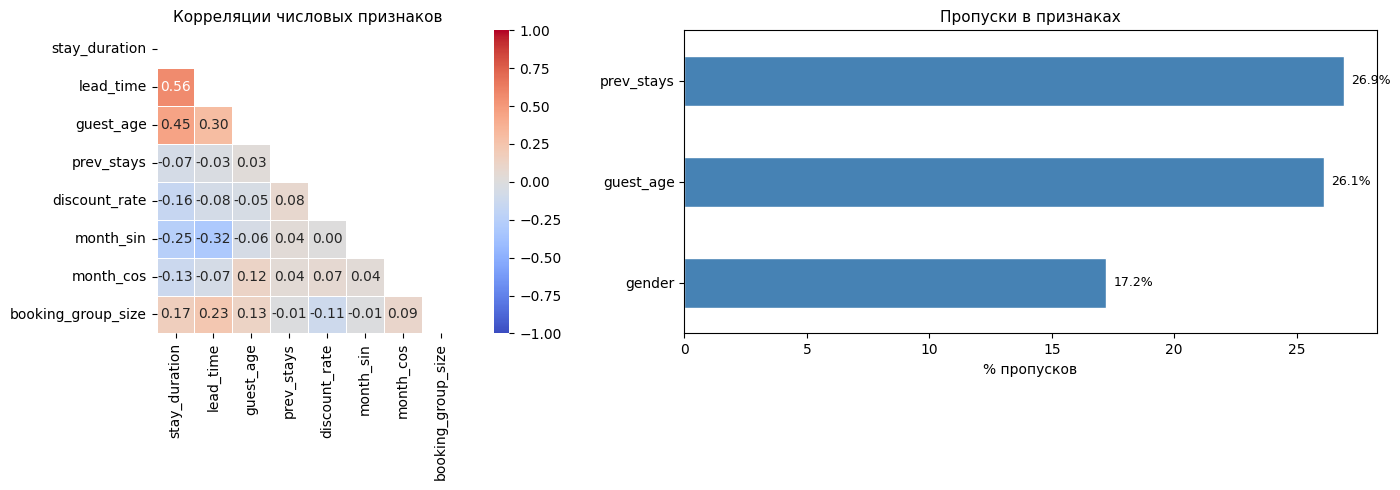

In [18]:
corr = df_model[X_NUM].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=axes[0],
            linewidths=0.5, square=True)
axes[0].set_title('Корреляции числовых признаков', fontsize=11)

# Пропуски
null_pct = (df_model[ALL_FEAT].isna().mean() * 100).sort_values(ascending=True)
null_pct = null_pct[null_pct > 0]
if len(null_pct):
    null_pct.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
    axes[1].set_xlabel('% пропусков')
    axes[1].set_title('Пропуски в признаках', fontsize=11)
    for i, v in enumerate(null_pct):
        axes[1].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)
else:
    axes[1].text(0.5, 0.5, 'Пропусков нет', ha='center', va='center',
                 transform=axes[1].transAxes, fontsize=14)
    axes[1].set_title('Пропуски в признаках', fontsize=11)

plt.tight_layout()
plt.show()

## 10. Агрегация до уровня гостя → df_for_model_claster

**Цель:** один гость = одна строка. Сейчас в df_model одна строка = один заезд.
Гость, приезжавший 5 раз, представлен 5 строками.

### Правила агрегации

| Признак | Агрегация | Логика |
|---|---|---|
| stay_duration | mean | Средняя длина заезда |
| lead_time | mean | Средний горизонт |
| guest_age | первый ненулевой | Атрибут гостя (стабильный) |
| prev_stays | max | Накопленная CRM-история |
| discount_rate | mean | Средняя скидка |
| month_sin, month_cos | mean | Типичная сезонность |
| **booking_group_size** | **mean** | **Средний размер группы по всем заездам** |
| gender | первый ненулевой | Атрибут гостя |
| has_children | max | 1 = хоть раз приезжал с детьми |
| is_weekend_in | mean | Доля weekend-заездов |
| tariff_group, room_group | mode | Типичный тариф/номер |


In [19]:
_first_nonnull = lambda x: x.dropna().iloc[0] if x.notna().any() else np.nan

num_agg = {
    'stay_duration':      'mean',
    'lead_time':          'mean',
    'guest_age':          _first_nonnull,
    'prev_stays':         'max',
    'discount_rate':      'mean',
    'month_sin':          'mean',
    'month_cos':          'mean',
    'booking_group_size': 'mean',   # средний размер группы по всем заездам
    'gender':             _first_nonnull,
    'has_children':       'max',
    'is_weekend_in':      'mean',
}
cat_agg = {
    'tariff_group': lambda x: x.mode().iloc[0],
    'room_group':   lambda x: x.mode().iloc[0],
}

g = df_model.groupby('guest_id')
df_for_model_claster = g.agg(num_agg)
df_for_model_claster[['tariff_group', 'room_group']] = (
    g[['tariff_group', 'room_group']].agg(cat_agg)
)
# n_stays — метаданные, в признаки X не включается
df_for_model_claster['n_stays'] = g['stay_duration'].count()
df_for_model_claster = df_for_model_claster.reset_index()

print(f"df_for_model_claster: {df_for_model_claster.shape[0]:,} гостей")
print(f"  (было {len(df_model):,} строк-заездов)")
print(f"\nbooking_group_size после агрегации:")
print(df_for_model_claster['booking_group_size'].describe().round(2))
print(f"\nПропуски: {df_for_model_claster[ALL_FEAT].isna().sum().sum()}")


df_for_model_claster: 436,492 гостей
  (было 485,897 строк-заездов)

booking_group_size после агрегации:
count    436492.00
mean         33.21
std          74.53
min           1.00
25%           2.00
50%           4.00
75%          32.00
max        1135.00
Name: booking_group_size, dtype: float64

Пропуски: 329056


In [20]:
# Быстрый взгляд на итоговый датасет
df_for_model_claster.head()

,guest_id,stay_duration,lead_time,guest_age,prev_stays,discount_rate,month_sin,month_cos,booking_group_size,gender,has_children,is_weekend_in,tariff_group,room_group,n_stays
0,15.0,8.000000,12.000000,NaN,NaN,10.0,-2.449294e-16,1.000000e+00,4.000000,NaN,0,0.000000,новогодний/банкет,стандарт,1
1,36.0,3.000000,13.000000,NaN,NaN,0.0,8.660254e-01,5.000000e-01,2.000000,NaN,0,1.000000,ультра/all-incl,стандарт,1
2,61.0,11.000000,38.500000,73.0,4.0,5.0,5.000000e-01,0.000000e+00,76.000000,Женский,1,0.000000,other,стандарт,2
3,72.0,9.666667,9.333333,36.0,6.0,0.0,1.220085e-01,4.553418e-01,6.666667,Мужской,0,0.333333,other,комфорт,3
4,73.0,9.333333,27.000000,16.0,3.0,0.0,5.773503e-01,1.480297e-16,8.666667,Мужской,0,0.666667,событие/группы,стандарт,3


## 11. Импутация пропусков + log1p-трансформация

### Импутация

| Признак | Стратегия | Обоснование |
|---|---|---|
| guest_age | median | Нейтральное заполнение (32% пропусков) |
| prev_stays | 0 | NaN = нет в CRM = первичный гость |
| gender | 'unknown' | Пол не удалось определить |

### log1p-трансформация

`prev_stays` (max=648, p99=24) и `lead_time` (max=689, p95=255) имеют экстремальный
правый хвост. При `StandardScaler` большинство значений сжимается у нуля, выбросы
уходят на ~100 сигм — KMeans начинает игнорировать все остальные признаки.

`log1p(x) = log(1+x)` сжимает хвост, сохраняет монотонность и ноль (`log1p(0)=0`).

**Порядок:** импутация → log1p → StandardScaler (в ColumnTransformer).

Пропуски после импутации:
stay_duration         0
lead_time             0
guest_age             0
prev_stays            0
discount_rate         0
month_sin             0
month_cos             0
booking_group_size    0
tariff_group          0
room_group            0
gender                0
has_children          0
is_weekend_in         0
dtype: int64


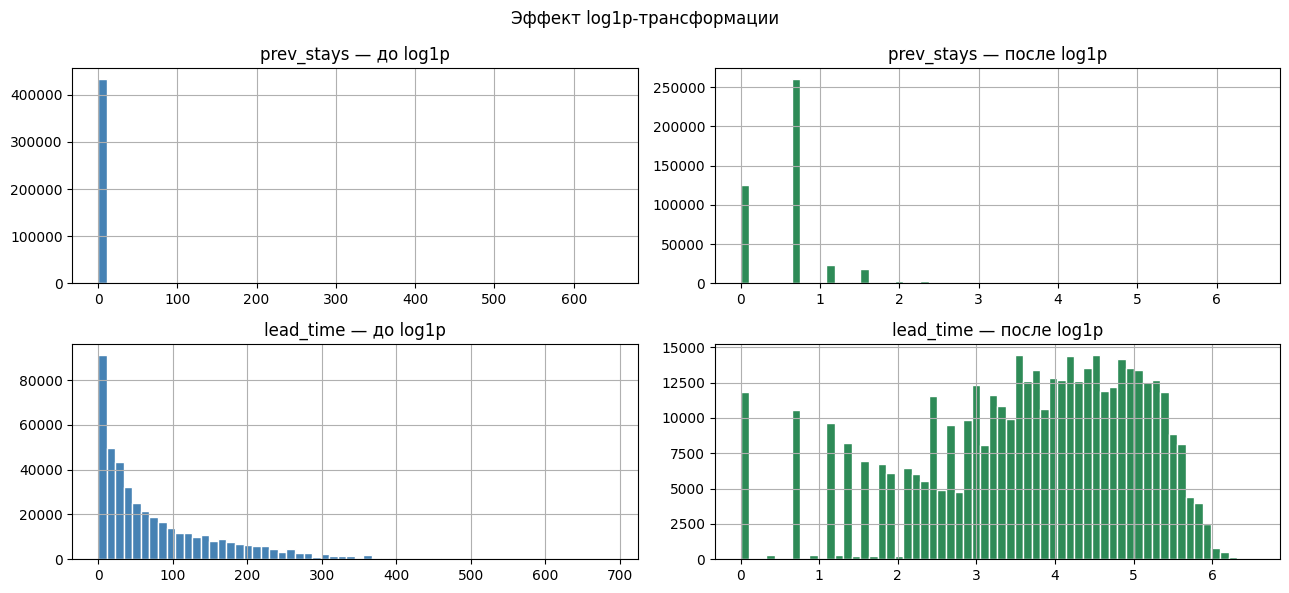


Статистика после log1p:
       prev_stays   lead_time
count  436492.000  436492.000
mean        0.587       3.652
std         0.475       1.418
min         0.000       0.000
25%         0.000       2.773
50%         0.693       3.871
75%         0.693       4.779
max         6.475       6.537


In [21]:
# ── Импутация ─────────────────────────────────────────────────────────────
df_for_model_claster['guest_age']  = df_for_model_claster['guest_age'].fillna(
    df_for_model_claster['guest_age'].median()
)
df_for_model_claster['prev_stays'] = df_for_model_claster['prev_stays'].fillna(0)
df_for_model_claster['gender']     = df_for_model_claster['gender'].fillna('unknown')

print("Пропуски после импутации:")
print(df_for_model_claster[ALL_FEAT].isna().sum())

# ── log1p ─────────────────────────────────────────────────────────────────
LOG_COLS = ['prev_stays', 'lead_time']

fig, axes = plt.subplots(2, 2, figsize=(13, 6))
for i, col in enumerate(LOG_COLS):
    df_for_model_claster[col].hist(bins=60, ax=axes[i][0],
                                   color='steelblue', edgecolor='white')
    axes[i][0].set_title(f'{col} — до log1p')
    np.log1p(df_for_model_claster[col]).hist(bins=60, ax=axes[i][1],
                                              color='seagreen', edgecolor='white')
    axes[i][1].set_title(f'{col} — после log1p')

plt.suptitle('Эффект log1p-трансформации', fontsize=12)
plt.tight_layout()
plt.show()

for col in LOG_COLS:
    df_for_model_claster[col] = np.log1p(df_for_model_claster[col])

print("\nСтатистика после log1p:")
print(df_for_model_claster[LOG_COLS].describe().round(3))

## 12. Распределения и баланс классов перед масштабированием

Проверяем:
- Числовые: нет ли доминирующих аномалий после log1p
- Категориальные: не доминирует ли одна категория (>80% → низкая информативность после OHE)
- Бинарные: не слишком ли редкий признак

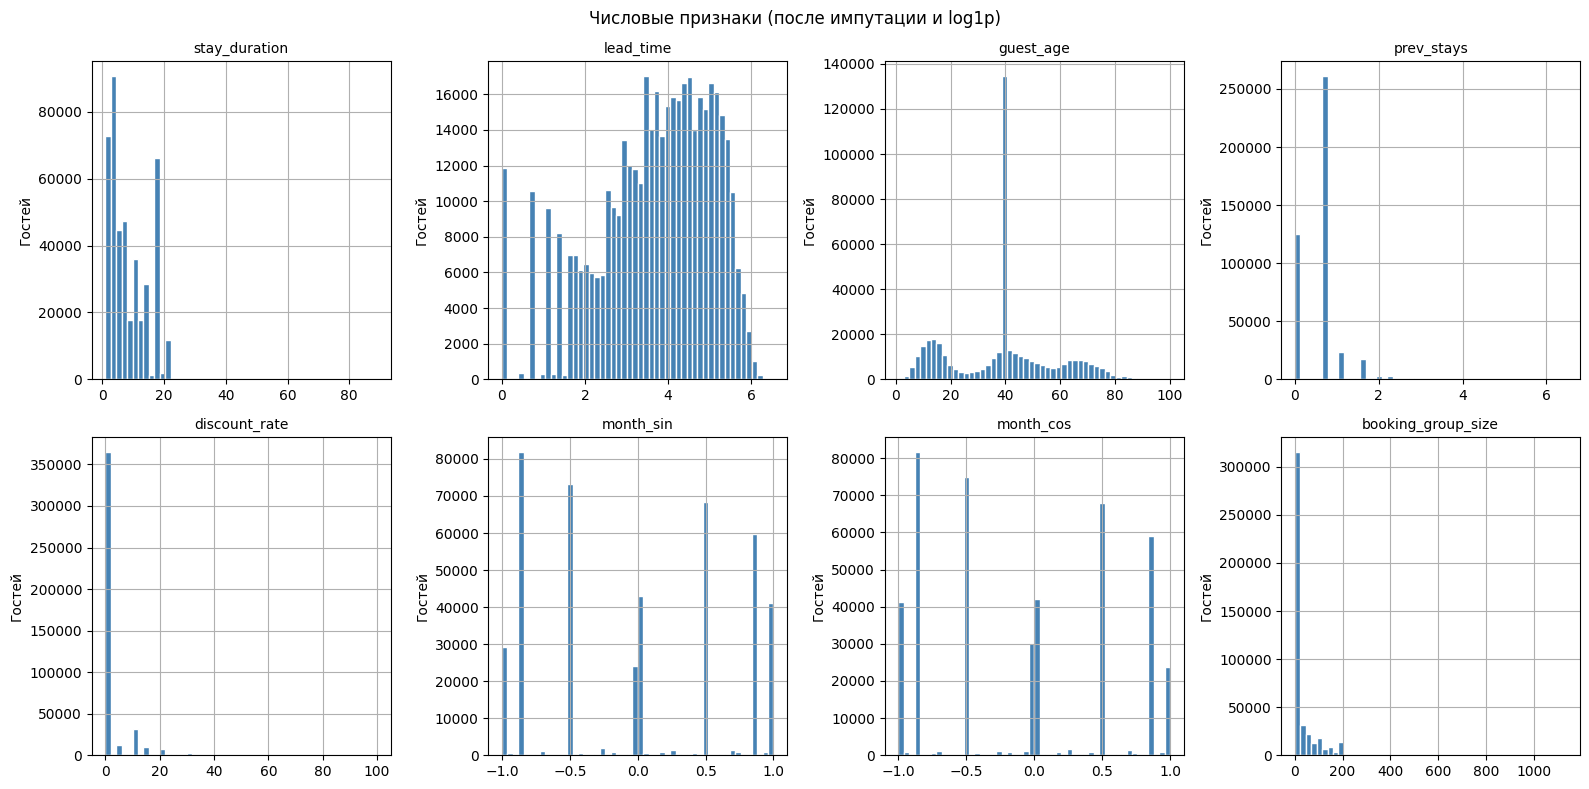

In [22]:
# Числовые распределения
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes_flat = axes.flatten()
for i, col in enumerate(X_NUM):
    df_for_model_claster[col].hist(bins=50, ax=axes_flat[i],
                                   color='steelblue', edgecolor='white')
    axes_flat[i].set_title(col, fontsize=10)
    axes_flat[i].set_ylabel('Гостей')
plt.suptitle('Числовые признаки (после импутации и log1p)', fontsize=12)
plt.tight_layout()
plt.show()

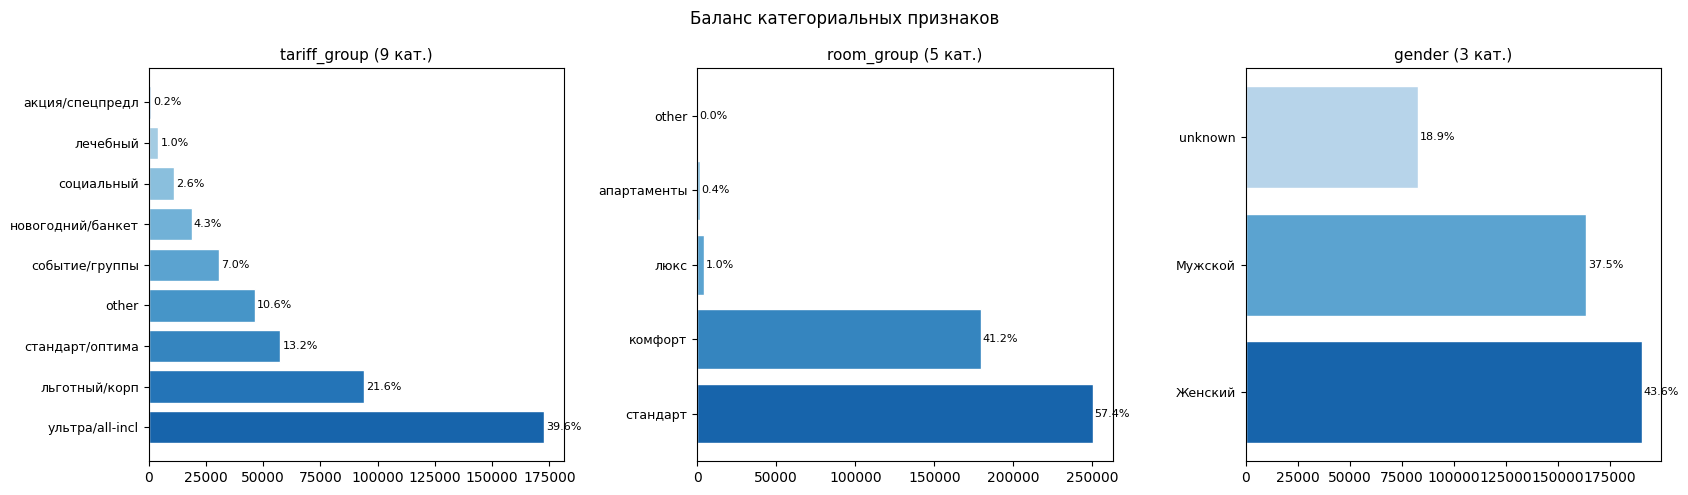

In [23]:
# Категориальные
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for i, col in enumerate(X_CAT):
    counts = df_for_model_claster[col].value_counts()
    pct    = (counts / len(df_for_model_claster) * 100).round(1)
    colors = plt.cm.Blues_r(np.linspace(0.2, 0.7, len(counts)))
    axes[i].barh(range(len(counts)), counts.values, color=colors, edgecolor='white')
    axes[i].set_yticks(range(len(counts)))
    axes[i].set_yticklabels(counts.index, fontsize=9)
    axes[i].set_title(f'{col} ({len(counts)} кат.)', fontsize=11)
    for j, (v, p) in enumerate(zip(counts.values, pct.values)):
        axes[i].text(v + len(df_for_model_claster)*0.002, j,
                     f'{p}%', va='center', fontsize=8)
plt.suptitle('Баланс категориальных признаков', fontsize=12)
plt.tight_layout()
plt.show()

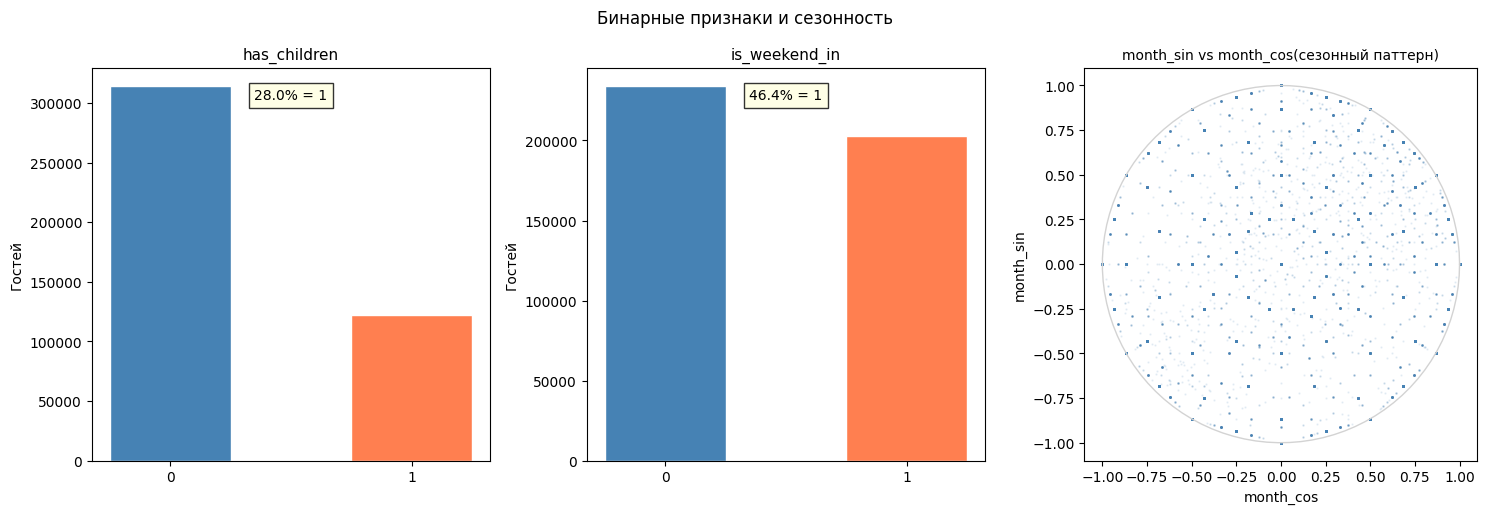

In [24]:
# Бинарные + сезонность
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(X_BIN):
    series = (df_for_model_claster[col] >= 0.5).astype(int)
    vc = series.value_counts().sort_index()
    vc = vc.reindex([0, 1], fill_value=0)
    axes[i].bar(['0', '1'], vc.values, color=['steelblue','coral'],
                edgecolor='white', width=0.5)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Гостей')
    pct1 = vc.get(1, 0) / len(df_for_model_claster) * 100
    axes[i].text(0.5, 0.92, f'{pct1:.1f}% = 1', ha='center',
                 transform=axes[i].transAxes, fontsize=10,
                 bbox=dict(facecolor='lightyellow', alpha=0.8))

# Сезонность (круговой паттерн)
theta = np.linspace(0, 2*np.pi, 100)
axes[2].plot(np.cos(theta), np.sin(theta), 'lightgray', linewidth=1)
axes[2].scatter(df_for_model_claster['month_cos'],
                df_for_model_claster['month_sin'],
                s=0.5, alpha=0.1, color='steelblue')
axes[2].set_aspect('equal'); axes[2].set_title('month_sin vs month_cos(сезонный паттерн)', fontsize=10)
axes[2].set_xlabel('month_cos'); axes[2].set_ylabel('month_sin')

plt.suptitle('Бинарные признаки и сезонность', fontsize=12)
plt.tight_layout()
plt.show()

## 13. Preprocessing Pipeline (ColumnTransformer) → X_scaled

### Стратегия

| Группа | Трансформация | Обоснование |
|---|---|---|
| Числовые (7) | `StandardScaler` | Разные единицы → нормировка обязательна для евклидовых метрик |
| Категориальные (3) | `OneHotEncoder` | KMeans работает только с числами |
| Бинарные (2) | `StandardScaler` | Без масштабирования [0,1] даёт в ~3× меньший вклад, чем числовые |

`handle_unknown='ignore'` в OHE — для корректной работы на новых данных.

**Итог:** X_scaled (numpy array) = 436 492 × (7 + K_ohe + 2), K_ohe = число OHE-колонок.

In [25]:
X_NUM = ['stay_duration', 'lead_time', 'guest_age', 'prev_stays',
         'discount_rate', 'month_sin', 'month_cos']
X_CAT = ['tariff_group', 'room_group', 'gender']
X_BIN = ['has_children', 'is_weekend_in']
X_COLS = X_NUM + X_CAT + X_BIN

preprocessor = ColumnTransformer([
    ('num', StandardScaler(),                                          X_NUM),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), X_CAT),
    ('bin', StandardScaler(),                                          X_BIN),
], remainder='drop')

X = df_for_model_claster[X_COLS]
X_scaled = preprocessor.fit_transform(X)

# Имена колонок для интерпретации
ohe_cols          = preprocessor.named_transformers_['cat'].get_feature_names_out(X_CAT).tolist()
feature_names_out = X_NUM + ohe_cols + X_BIN

print(f"Матрица X_scaled: {X_scaled.shape[0]:,} гостей × {X_scaled.shape[1]} признаков")
print(f"  Числовые  (StandardScaler) : {len(X_NUM):>2} признака")
print(f"  OHE-признаки               : {len(ohe_cols):>2} колонок (из {len(X_CAT)} категориальных)")
print(f"  Бинарные  (StandardScaler) : {len(X_BIN):>2} признака")
print(f"  Итого                      : {len(feature_names_out):>2} колонок")
print(f"\nПропуски в X_scaled: {int(np.isnan(X_scaled).sum())} (должно быть 0)")

Матрица X_scaled: 436,492 гостей × 26 признаков
  Числовые  (StandardScaler) :  7 признака
  OHE-признаки               : 17 колонок (из 3 категориальных)
  Бинарные  (StandardScaler) :  2 признака
  Итого                      : 26 колонок

Пропуски в X_scaled: 0 (должно быть 0)


Дисперсия по группам признаков (после масштабирования):
  Числовые  std: [1. 1. 1. 1. 1. 1. 1.]
  Бинарные  std: [1. 1.]
  OHE mean std:  0.285  (OHE в [0,1] — ограничение mixed-data)


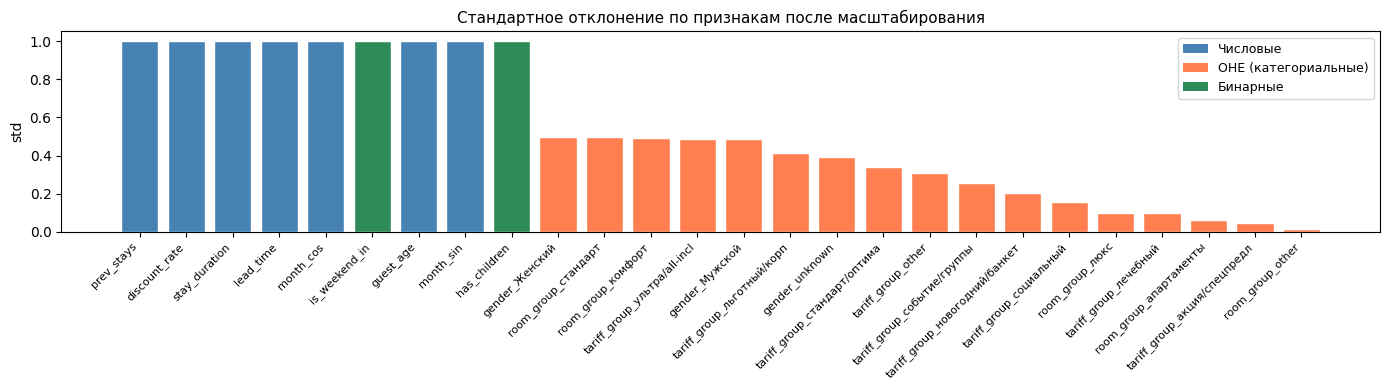

In [26]:
# Проверка масштаба по группам признаков
X_df = pd.DataFrame(X_scaled, columns=feature_names_out)

print("Дисперсия по группам признаков (после масштабирования):")
print(f"  Числовые  std: {X_df[X_NUM].std().round(3).values}")
print(f"  Бинарные  std: {X_df[X_BIN].std().round(3).values}")
print(f"  OHE mean std:  {X_df[ohe_cols].std().mean():.3f}  (OHE в [0,1] — ограничение mixed-data)")

# Распределение дисперсий
fig, ax = plt.subplots(figsize=(14, 4))
stds = X_df.std().sort_values(ascending=False)
colors_list = (['steelblue'] * len(X_NUM) +
               ['coral'] * len(ohe_cols) +
               ['seagreen'] * len(X_BIN))
color_map = {col: 'steelblue' for col in X_NUM}
color_map.update({col: 'coral' for col in ohe_cols})
color_map.update({col: 'seagreen' for col in X_BIN})
bar_colors = [color_map.get(c, 'gray') for c in stds.index]
ax.bar(range(len(stds)), stds.values, color=bar_colors, edgecolor='white', width=0.8)
ax.set_xticks(range(len(stds)))
ax.set_xticklabels(stds.index, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('std')
ax.set_title('Стандартное отклонение по признакам после масштабирования', fontsize=11)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='Числовые'),
                   Patch(facecolor='coral',     label='OHE (категориальные)'),
                   Patch(facecolor='seagreen',  label='Бинарные')]
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.show()

## 14. Финальная проверка — данные готовы к моделированию

Все преобразования завершены. Переменные для передачи в модели:

In [27]:
print("=" * 65)
print("  ДАННЫЕ ГОТОВЫ К КЛАСТЕРИЗАЦИИ")
print("=" * 65)

print(f"\n1. ИСХОДНЫЕ ДАННЫЕ")
print(f"   silver.csv                         : 565 816 строк")
print(f"   После фильтра (is_valid=1)          : {len(df):,} строк")
print(f"   После схлопывания (grp_norm,guest)  : {len(df_deduped):,} строк")
print(f"   После очистки (nights, служебные)  : {len(df_clean):,} строк")

print(f"\n2. ИТОГОВЫЙ ДАТАСЕТ")
print(f"   df_for_model_claster               : {len(df_for_model_claster):,} гостей")
print(f"   X_scaled                           : {X_scaled.shape}")
print(f"   Пропуски                           : {int(np.isnan(X_scaled).sum())} ✓")
print(f"   Тип данных                         : {X_scaled.dtype}")

print(f"\n3. ПРИЗНАКИ (X_COLS = {len(X_COLS)} исходных → {X_scaled.shape[1]} после OHE)")
for col in X_COLS:
    t = 'num' if col in X_NUM else ('cat' if col in X_CAT else 'bin')
    print(f"   {col:<20} [{t}]")

print(f"\n4. ПЕРЕМЕННЫЕ ДЛЯ МОДЕЛИРОВАНИЯ")
print(f"   X        = df_for_model_claster[X_COLS]   ({X.shape})")
print(f"   X_scaled = preprocessor.fit_transform(X)  ({X_scaled.shape})")
print(f"   preprocessor  — обученный ColumnTransformer")
print(f"   feature_names_out — список имён после OHE ({len(feature_names_out)} шт.)")

print(f"\n5. ПРИМЕНЁННЫЕ ПРЕОБРАЗОВАНИЯ")
transformations = [
    ("guest_age",    "fillna(median)",   "32% пропусков → медиана"),
    ("prev_stays",   "fillna(0)",        "NaN = нет в CRM → первичный"),
    ("gender",       "fillna('unknown')","пол неизвестен"),
    ("prev_stays",   "log1p",            "max=648, p99=24 → сжатие хвоста"),
    ("lead_time",    "log1p",            "max=689, p95=255 → сжатие хвоста"),
    ("X_num + X_bin","StandardScaler",   "нормировка к mean=0, std≈1"),
    ("X_cat",        "OHE",              f"{len(ohe_cols)} бинарных колонок"),
]
for feat, tr, reason in transformations:
    print(f"   {feat:<20} → {tr:<18} ({reason})")

print("\n✅ Следующий шаг: секция 'Сравнение алгоритмов' → KMeans + Agglomerative + DBSCAN + GMM + Spectral")

  ДАННЫЕ ГОТОВЫ К КЛАСТЕРИЗАЦИИ

1. ИСХОДНЫЕ ДАННЫЕ
   silver.csv                         : 565 816 строк
   После фильтра (is_valid=1)          : 521,143 строк
   После схлопывания (grp_norm,guest)  : 486,060 строк
   После очистки (nights, служебные)  : 485,897 строк

2. ИТОГОВЫЙ ДАТАСЕТ
   df_for_model_claster               : 436,492 гостей
   X_scaled                           : (436492, 26)
   Пропуски                           : 0 ✓
   Тип данных                         : float64

3. ПРИЗНАКИ (X_COLS = 12 исходных → 26 после OHE)
   stay_duration        [num]
   lead_time            [num]
   guest_age            [num]
   prev_stays           [num]
   discount_rate        [num]
   month_sin            [num]
   month_cos            [num]
   tariff_group         [cat]
   room_group           [cat]
   gender               [cat]
   has_children         [bin]
   is_weekend_in        [bin]

4. ПЕРЕМЕННЫЕ ДЛЯ МОДЕЛИРОВАНИЯ
   X        = df_for_model_claster[X_COLS]   ((436492, 12))
   X_